En el siguiente código, configuramos la API de Google Gemini para que la función trabaje y pueda entregar un resultado cuando se le llame

In [8]:
!pip install -q google-generativeai ipywidgets pillow

import os
import google.generativeai as genai
from IPython.display import Markdown, Image as IPyImage , clear_output, display
import ipywidgets as widgets
import io
from PIL import Image

# Clave de API de Google AI Studio
API_KEY = "poner_api_key_aqui"

genai.configure(api_key=API_KEY)

print("Entorno y cliente configurados con exito.")

Entorno y cliente configurados con exito.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Una vez ya conectada la API, hacemos un ejemplos, esta vez sin subir imágenes al programa parra ver como este se comporta.
1. Subimos un ejemplo de la descrición detallada de una prenda
2. Hacemos el prompt para el zero prompt shooting
3. Hacemos lo mismo con el one shoot prompting

In [36]:
# 1. Prenda base que se usará para la prueba con la API
datos_prenda_actual = """
- Tipo de prenda: Hoodie oversized con bolsillo canguro
- Composición y color: Algodón rústico pesado 400 GSM, color verde oliva
- Perfil del modelo: Hombre joven de contextura atlética, cabello corto ondulado
- Valores de marca: Minimalismo urbano, alta durabilidad, corte contemporáneo
"""

# 2. Prompt usando zero prompt shooting, es decir sin ejemplos previos
prompt_zero_shot = f"""
<role>
Actúa como director de arte de moda.</role>
<task> Con estos datos de la prenda:
{datos_prenda_actual}

Genera:
1. Una descripción comercial para tienda online.
2. Un prompt en inglés para foto de catálogo en estudio (fondo blanco).
3. Un prompt en inglés para foto editorial en la calle.
</task>
"""

# 3. Prompt usando one shoot prompting con un ejemplo de guía
prompt_one_shot = f"""
<role> Rol: Actúa como director de arte de fotografía y especialista en prompt engineering para e-commerce de moda.</role>
<context> Contexto: Una marca de moda urbana necesita estandarizar la ficha técnica de una prenda y generar los prompts técnicos para su producción visual en dos formatos: catálogo de estudio y campaña editorial. </context>

---
<example>
### EJEMPLO DE GUIA (ONE-SHOT):
Lo que vas a recibir:
- Tipo de prenda: Chaqueta Bomber impermeable
- Composición y color: Poliéster reciclado, color negro mate
- Perfil del modelo: Mujer joven contextura delgada, cabello liso
- Valores de marca: Estilo urbano técnico, resistencia al agua

Salida esperada:
Ficha comercial: Chaqueta Bomber urbana con acabado mate impermeable. Confeccionada con textil técnico de alta resistencia, cuello acanalado y cierre frontal reforzado. Ideal para climas cambiantes con el máximo estilo.
- Impermeabilidad de grado urbano
- Textil ultraligero y térmico
- Calce regular fit contemporáneo

Prompt técnico catálogo e-commerce: Commercial studio fashion photography of a young woman with slim build and straight hair wearing a matte black waterproof bomber jacket, clean seamless pure white background, professional three-point softbox lighting, 85mm lens, f/8, sharp focus on waterproof fabric texture, high-end clean e-commerce catalog look --ar 4:5

Prompt técnico campaña editorial: Editorial streetwear lifestyle photography of a young woman wearing a matte black bomber jacket in a rainy modern city street, warm neon lights reflection on wet pavement, candid walking posture, 35mm film aesthetic, shallow depth of field --ar 16:9
</example>
---
<task>
### TAREA ACTUAL:
Lo que vas a recibir:
{datos_prenda_actual}

Instrucciones:
1. Redacta una descripción de producto para e-commerce (100-120 palabras) con tono moderno, persuasivo y estructurado en viñetas de valor.
2. Construye un meta-prompt en inglés para fotografía de catálogo e-commerce (estudio, fondo blanco, iluminación uniforme, detalle de tejido).
3. Construye un meta-prompt en inglés para fotografía editorial lifestyle (entorno urbano exterior, luz natural, encuadre cinematográfico).

Consigna de salida:
Ficha comercial: incluye descripción persuasiva y especificaciones técnicas.
Prompt técnico catálogo e-commerce: incluye prompt en inglés con modificadores de cámara, iluminación y fondo.
Prompt técnico campaña editorial: incluye prompt en inglés con atmósfera urbana, ángulo de toma y composición.
</task>
"""


Hacemos la prueba ahora con one shot prompting para mandarsela a la API de Gemini

In [37]:
# Aquí consultamos a la API de Gemini
def generar_estrategia(prompt_a_enviar):
    """Realiza una sola consulta al modelo de lenguaje para obtener la ficha

    comercial y los dos prompts tecnicos de imagen.
    """
    modelo = genai.GenerativeModel("gemini-3.5-flash")
    respuesta = modelo.generate_content(
        prompt_a_enviar,
        generation_config=genai.types.GenerationConfig(
            temperature=0.3,
        ),
    )
    return respuesta.text


# Ejecutamos la función usando one shot prompting
print("Generando propuesta con enfoque One-Shot...")
resultado_one_shot = generar_estrategia(prompt_one_shot)

display(Markdown(resultado_one_shot))

Generando propuesta con enfoque One-Shot...


### Ficha comercial:
Eleva tu estilo diario con nuestro Hoodie Oversized en color verde oliva, una pieza clave que fusiona el minimalismo urbano con una resistencia superior. Confeccionado en algodón rústico pesado de 400 GSM, este hoodie ofrece una estructura imponente y un tacto robusto que mantiene su forma lavado tras lavado. Su diseño contemporáneo de hombros caídos y bolsillo canguro funcional redefine la comodidad urbana, convirtiéndolo en el básico definitivo para quienes exigen durabilidad y diseño sin esfuerzo.

*   **Algodón rústico premium de 400 GSM** para máxima estructura, abrigo y alta durabilidad.
*   **Corte oversized contemporáneo** con caída de hombros relajada y ajuste moderno.
*   **Detalles minimalistas:** Bolsillo canguro reforzado y capucha de doble capa sin cordones para un look limpio y depurado.

---

### Prompt técnico catálogo e-commerce:
> Commercial studio fashion photography of a young athletic man with short wavy hair wearing an olive green oversized heavyweight cotton hoodie, clean seamless pure white background, professional high-key softbox lighting, 85mm lens, f/8, sharp focus on the premium 400 GSM rustic cotton fabric texture, high-end clean e-commerce catalog look --ar 4:5

---

### Prompt técnico campaña editorial:
> Editorial streetwear lifestyle photography of a young athletic man with short wavy hair wearing an olive green oversized heavyweight hoodie, standing in a minimalist concrete urban architectural setting, soft natural golden hour backlight, low angle shot, cinematic composition, 50mm lens, f/2.0, shallow depth of field, moody and authentic atmosphere --ar 16:9

Hacemos una segunda prueba pero esta vez usando la IA de imagenes con el fin de ver el resultado final

In [38]:
# Se crea una función para hacer un catálogo personalizado en el que somos capaces de describirle la prenda que vamos a usar.
def generar_catalogo_personalizado(prenda, material, modelo, estilo):
    prompt_personalizado = f"""
<role>Rol: Actúa como director de arte de fotografía y especialista en prompt engineering para e-commerce de moda. </role>
<context>Contexto: Una marca de moda urbana necesita estandarizar la ficha técnica de una prenda y generar los prompts técnicos para su producción visual en dos formatos: catálogo de estudio y campaña editorial.</context>

---
<example>
### EJEMPLO DE GUIA (ONE-SHOT):
Lo que vas a recibir:
- Tipo de prenda: Chaqueta Bomber impermeable
- Composición y color: Poliéster reciclado, color negro mate
- Perfil del modelo: Mujer joven contextura delgada, cabello liso
- Valores de marca: Estilo urbano técnico, resistencia al agua

Salida esperada:
Ficha comercial: Chaqueta Bomber urbana con acabado mate impermeable. Confeccionada con textil técnico de alta resistencia, cuello acanalado y cierre frontal reforzado. Ideal para climas cambiantes con el máximo estilo.
- Impermeabilidad de grado urbano
- Textil ultraligero y térmico
- Calce regular fit contemporáneo

Prompt técnico catálogo e-commerce: Commercial studio fashion photography of a young woman with slim build and straight hair wearing a matte black waterproof bomber jacket, clean seamless pure white background, professional three-point softbox lighting, 85mm lens, f/8, sharp focus on waterproof fabric texture, high-end clean e-commerce catalog look --ar 4:5

Prompt técnico campaña editorial: Editorial streetwear lifestyle photography of a young woman wearing a matte black bomber jacket in a rainy modern city street, warm neon lights reflection on wet pavement, candid walking posture, 35mm film aesthetic, shallow depth of field --ar 16:9
</example>
---
<task>
### TAREA ACTUAL:
Lo que vas a recibir:
- Tipo de prenda: {prenda}
- Composición y color: {material}
- Perfil del modelo: {modelo}
- Valores de marca: {estilo}

Instrucciones:
1. Redacta una descripción de producto para e-commerce (100-120 palabras) con tono moderno, persuasivo y estructurado en viñetas de valor.
2. Construye un meta-prompt en inglés para fotografía de catálogo e-commerce (estudio, fondo blanco, iluminación uniforme, detalle de tejido).
3. Construye un meta-prompt en inglés para fotografía editorial lifestyle (entorno urbano exterior, luz natural, encuadre cinematográfico).

Consigna de salida:
Ficha comercial: incluye descripción persuasiva y especificaciones técnicas.
Prompt técnico catálogo e-commerce: incluye prompt en inglés con modificadores de cámara, iluminación y fondo.
Prompt técnico campaña editorial: incluye prompt en inglés con atmósfera urbana, ángulo de toma y composición.
</task>
"""
    return generar_estrategia(prompt_personalizado)


# Con estos apartados, se peude cambiar la descripción de la prenda
prenda_test = "Camiseta oversize cuello redondo"
material_test = "Algodon peinado 240 GSM, color arena desierto"
modelo_test = "Mujer joven de contextura media, cabello castano suelto"
estilo_test = "Streetwear minimalista, corte relajado"

print(f"Procesando: {prenda_test}...")
resultado_nuevo = generar_catalogo_personalizado(
    prenda_test, material_test, modelo_test, estilo_test
)

# Mostramos el resultado
display(Markdown(resultado_nuevo))

Procesando: Camiseta oversize cuello redondo...


### Ficha comercial

**Descripción del producto:**
Eleva tu rotación diaria con nuestra camiseta *oversize* en tono arena desierto, una pieza esencial que define el *streetwear* minimalista contemporáneo. Confeccionada en algodón peinado de 240 GSM, esta prenda ofrece un gramaje pesado (*heavyweight*) que garantiza una caída estructural perfecta y una durabilidad excepcional. Su diseño de hombros caídos, cuello redondo acanalado de alta resistencia y silueta relajada proporciona la máxima comodidad sin perder sofisticación. Es la fusión perfecta entre la estética urbana de vanguardia y el confort premium de uso diario.

*   **Textil Heavyweight:** Algodón peinado de 240 GSM para una estructura y caída premium.
*   **Corte Relaxed Fit:** Silueta *oversize* unisex con hombros caídos de estética contemporánea.
*   **Paleta Orgánica:** Tono arena desierto, altamente versátil y fácil de combinar.

---

### Prompt técnico catálogo e-commerce

> **Prompt:** Commercial studio fashion photography of a young woman with medium build and loose brown hair, wearing a desert sand-colored oversized crewneck t-shirt made of heavy 240 GSM combed cotton. Clean seamless pure white background. Professional three-point softbox lighting, bright and even illumination. Shot on 85mm lens, f/8, sharp focus on the premium heavy cotton fabric texture and relaxed fit drape. High-end clean e-commerce catalog look, professional color grading --ar 4:5

---

### Prompt técnico campaña editorial

> **Prompt:** Editorial streetwear lifestyle photography of a young woman with medium build and loose brown hair, wearing a desert sand oversized crewneck t-shirt. Set against a minimalist brutalist concrete architecture background in a modern city. Soft natural golden hour sunlight casting gentle shadows, cinematic composition, candid relaxed walking posture. Shot on 35mm lens, f/2.8, shallow depth of field, subtle film grain aesthetic, muted warm color grading, high fashion look --ar 16:9

Este código va ligado al anterior, pues después de que la IA nos mande los 2 prompts en inglés, nos dirigimos en este caso a NanoBanana Pro y le pegamos los prompts para que genere la imágen (Puede funcionar con cualquier IA gratuita o de pago)

En este caso no usamos la API ya que esta solo funciona con los modelos de texto y para poder usar la IA de imágen con la API, se necesita de pagarla además del plan con suscripción.

### Muestra de Resultados Visuales Generados

1. Fotografia de catalogo e-commerce (Estudio - Fondo Blanco):


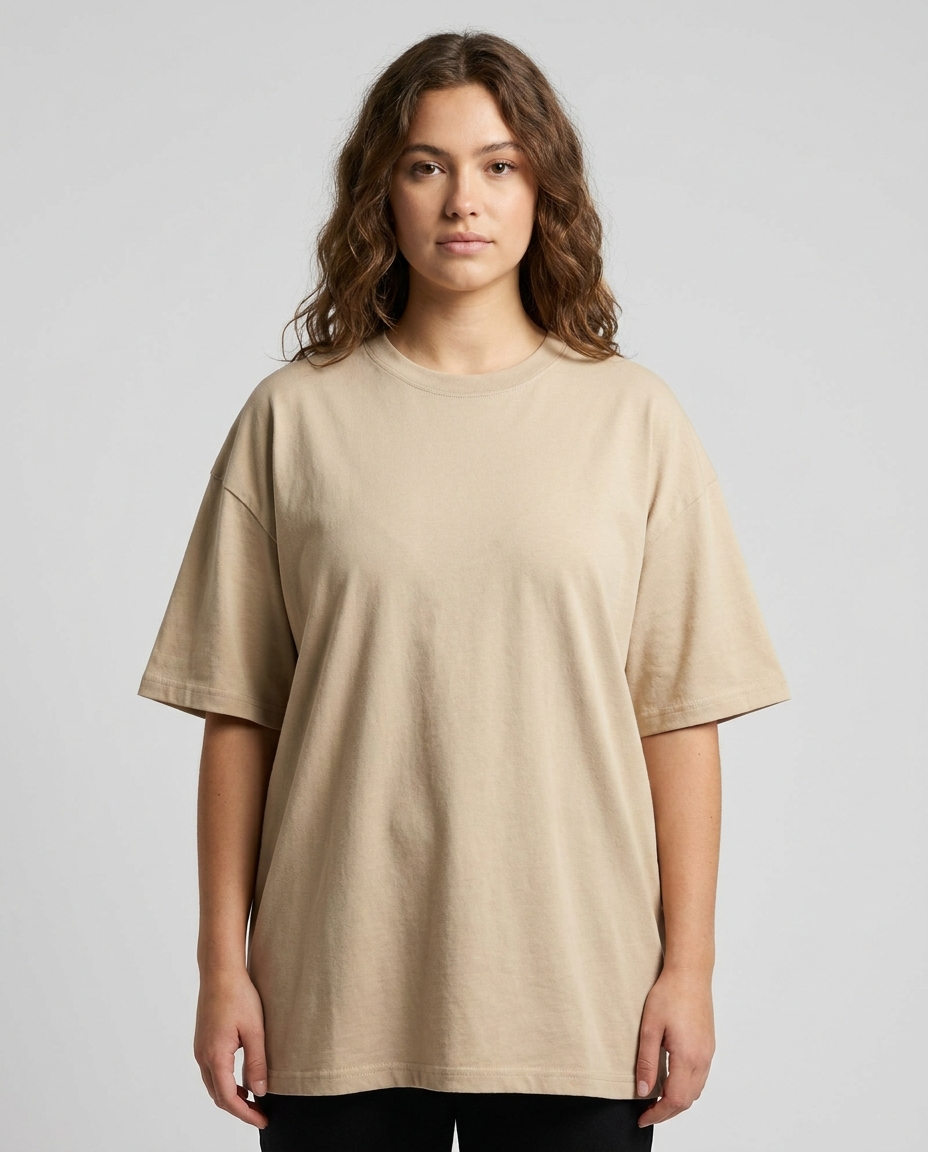

2. Fotografia de campana editorial (Urbana - Exterior):


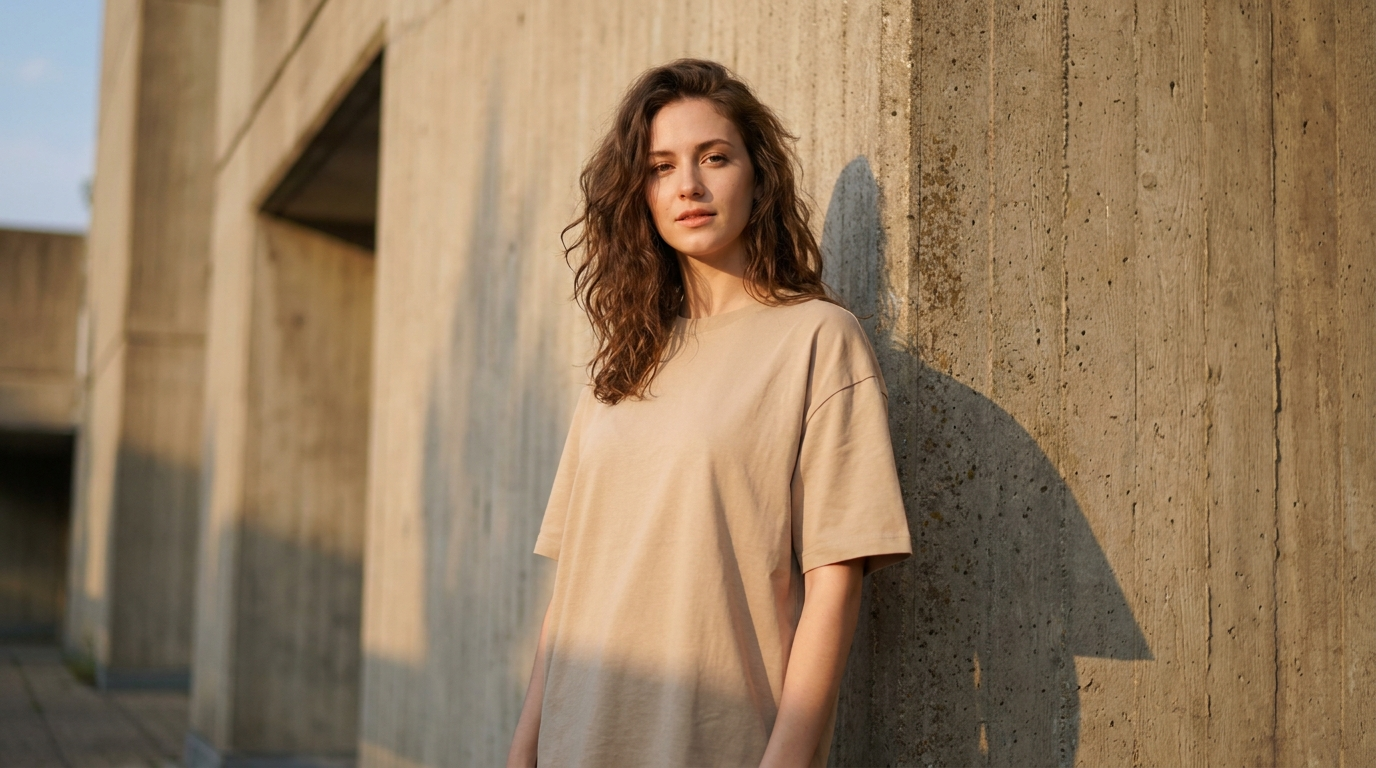

In [ ]:
# Creamos una carpeta llamadas Assets para guardar las imágenes y que el programa sea capaz de ir a buscarla y mostrarla aquí abajo

# Rutas de los archivos de imagen
ruta_catalogo = "assets/catalogo_estudio.jpg"
ruta_editorial = "assets/campana_editorial.jpg"

display(Markdown("### Muestra de Resultados Visuales Generados"))

# Visualizacion de la foto de catalogo
if os.path.exists(ruta_catalogo):
    print("1. Fotografia de catalogo e-commerce (Estudio - Fondo Blanco):")
    display(IPyImage(filename=ruta_catalogo, width=450))
else:
    print(
        f"Aviso: Guarda la imagen de catalogo en '{ruta_catalogo}' para visualizarla aqui."
    )

# Visualizacion de la foto editorial
if os.path.exists(ruta_editorial):
    print("2. Fotografia de campana editorial (Urbana - Exterior):")
    display(IPyImage(filename=ruta_editorial, width=450))
else:
    print(
        f"Aviso: Guarda la imagen editorial en '{ruta_editorial}' para visualizarla aqui."
    )

Por último, quise ir un poco más allá e intentar automatizar esto un poco más de manera que fuera más sencillo para el usuario utilizar la herramienta.

Esto es lo que se ejecuta

1. Se despliega un contenedor que proporciona espacios para que el cliente los llene a su conveniencia, entre ellos se encuentra

- Un espacio para subir la foto de la prenda colgada en un gancho o en una mesa para que la IA la pueda visualizar fácilmente
- El tipo de prompt que se quiere mandar: zero, one o few shoot prompting para que cree los 2 prompts para la IA de imágen
- Tipo de catálogo: puede escoger entre 4 opciones de fondo de la foto para que la IA se lo describa en el prompt
- Modelo: Se describe a la persona la cual desea que use la prenda
- Locación calle: Se describe el lugar al aire libre para la foto editorial y para que la IA la describa en inglés de forma detallada

2. Una vez se llenan los espacios, el programa llama a la API y pide la respuesta a la IA para después devolversela al usuario

In [6]:


# Se hace la descripción e los fondos de catálogos
PRESETS_CATALOGO = {
    "1. Estudio E-commerce Clasico (Fondo Blanco / Softbox)": (
        "Seamless pure white background (#FFFFFF), professional three-point softbox lighting, "
        "even diffused light without harsh shadows, 85mm telephoto portrait lens, f/8 aperture, "
        "pin-sharp textile weave and stitch details, clean commercial lookbook style --ar 4:5"
    ),
    "2. Estudio Editorial Minimalista (Ciclorama Beige / Luz Calida)": (
        "Warm neutral off-white/beige cyclorama studio, soft directional warm morning sunlight simulation, "
        "subtle soft-edged architectural shadows, 50mm prime lens, f/4 aperture, elegant contemporary high-fashion aesthetic --ar 4:5"
    ),
    "3. Estudio High-End / Contraste (Gris Neutro / Rim Light)": (
        "Matte neutral grey studio backdrop, dramatic rim light separating model from background, "
        "sculpted high-contrast studio strobe lighting, 85mm lens, f/5.6 aperture, sharp technical athletic edge --ar 4:5"
    ),
    "4. Estudio Lookbook Zen (Textura Arena / Luz Cenital Difusa)": (
        "Warm sand-toned textured concrete wall backdrop, soft overhead diffused natural ambient lighting, "
        "organic soft tones, 35mm lens medium shot, relaxed modern lifestyle catalog aesthetic --ar 4:5"
    ),
}

# Proporción de ejemplos para one y few shoot prompting
EJEMPLO_1 = """
<example>
Ejemplo 1:
- Prenda: Chaqueta Bomber impermeable en poliester reciclado negro mate.
- Salida esperada:
  * Ficha comercial: Chaqueta Bomber urbana confeccionada en textil tecnico reciclado con acabado mate hidrofugo. Su estructura ligera y cuello acanalado proporcionan aislamiento termico y estilo contemporaneo.
    - Textil tecnico resistente al agua
    - Aislamiento termico ultraligero
    - Corte regular fit con cierres reforzados
  * Prompt catalogo: Commercial studio fashion photography of a model wearing a matte black waterproof bomber jacket, clean seamless white background, professional three-point softbox lighting, 85mm lens, f/8, sharp focus on waterproof fabric texture --ar 4:5
  * Prompt editorial: Editorial streetwear lifestyle photography of a model wearing a matte black bomber jacket in a modern rainy downtown street, reflections on wet pavement, candid walking posture, 35mm film aesthetic, cinematic lighting --ar 16:9
</example>
"""

EJEMPLO_2 = """
<example>
Ejemplo 2:
- Prenda: Camisa de lino resort fit en tono arena natural.
- Salida esperada:
  * Ficha comercial: Camisa de corte relajado elaborada en lino 100% transpirable. Cuello cubano y textura abierta que garantizan maxima frescura en climas calidos con sofisticacion atemporal.
    - Fibra natural de lino de alto gramaje
    - Estructura transpirable antibacteriana
    - Cuello resort con caida fluida
  * Prompt catalogo: Commercial studio fashion photography of a model wearing a relaxed sand-toned linen shirt, beige neutral studio cyclorama, soft warm key light, 85mm lens, f/5.6, visible organic fabric weave --ar 4:5
  * Prompt editorial: Editorial summer resort photography of a model wearing an open sand linen shirt on a coastal architectural terrace, golden hour warm side-lighting, 50mm lens, relaxed aesthetic --ar 16:9
</example>
"""

EJEMPLO_3 = """
<example>
Ejemplo 3:
- Prenda: Pantalon Cargo utilitario en denim rigido indigo oscuro.
- Salida esperada:
  * Ficha comercial: Pantalon utilitario en denim de 13 oz con tratamiento de lavado enzimatico. Multiples bolsillos de fuelle funcionales y rodillas preformadas para resistencia extrema y movilidad.
    - Denim indigo pesado de alta resistencia
    - Bolsillos cargo estructurados
    - Calce relaxed-tapered contemporaneo
  * Prompt catalogo: Commercial studio fashion photography of a model wearing dark indigo cargo denim pants, solid neutral grey backdrop, crisp studio rim light, 85mm lens, f/8, sharp stitch details --ar 4:5
  * Prompt editorial: Editorial raw urban photography of a model wearing dark denim cargo pants sitting on industrial concrete steps, natural overcast soft daylight, wide 35mm composition --ar 16:9
</example>
"""

# Se crea la interfaz gráfica para que el usuario elija cada opción
subir_imagen = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Subir Prenda",
    button_style="info",
    tooltip="Sube una foto de la prenda en mesa o gancho",
)

selector_estrategia = widgets.Dropdown(
    options=[
        "Zero-Shot (Instruccion directa sin ejemplos)",
        "One-Shot (1 Ejemplo de referencia tecnica)",
        "Few-Shot (3 Ejemplos multi-categoria)",
    ],
    value="Few-Shot (3 Ejemplos multi-categoria)",
    description="Estrategia:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="90%"),
)

selector_catalogo = widgets.Dropdown(
    options=list(PRESETS_CATALOGO.keys()),
    value="1. Estudio E-commerce Clasico (Fondo Blanco / Softbox)",
    description="Setup Catalogo:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="90%"),
)

txt_modelo = widgets.Text(
    value="Hombre joven atletico, cabello corto ondulado, expresion neutra y moderna",
    description="Modelo:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="90%"),
)

txt_locacion_editorial = widgets.Textarea(
    value="Paseo peatonal frente a un museo moderno de concreto y ventanales amplios, piso humedo tras una lluvia ligera, luz natural de tarde nublada.",
    description="Locacion Calle:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="90%", height="75px"),
)

btn_procesar = widgets.Button(
    description="Generar Ficha y Prompts Tecnicos",
    button_style="primary",
    layout=widgets.Layout(width="300px", height="42px"),
)

area_salida = widgets.Output()


# Se le da las instrucciones al programa de qué hacer con cada una de la información proporcionada
def procesar_estrategia_visual(b):
    with area_salida:
        area_salida.clear_output()

        if not subir_imagen.value:
            print("Aviso: Carga una foto de la prenda usando el boton 'Subir Prenda'.")
            return

        print("Analizando la prenda con Gemini...")

        try:
            archivo = (
                subir_imagen.value[0]
                if isinstance(subir_imagen.value, (list, tuple))
                else list(subir_imagen.value.values())[0]
            )
            contenido = (
                archivo["content"] if "content" in archivo else archivo["data"]
            )
            imagen_pil = Image.open(io.BytesIO(contenido))

            preset_tecnico = PRESETS_CATALOGO[selector_catalogo.value]
            estrategia = selector_estrategia.value

            bloque_ejemplos = ""
            if "One-Shot" in estrategia:
                bloque_ejemplos = f"\n### GUIA DE REFERENCIA (ONE-SHOT):\n{EJEMPLO_1}\n---\n"
            elif "Few-Shot" in estrategia:
                bloque_ejemplos = f"\n### GUIA DE REFERENCIA MULTI-CATEGORIA (FEW-SHOT):\n{EJEMPLO_1}\n{EJEMPLO_2}\n{EJEMPLO_3}\n---\n"

            prompt_sistema = f"""
            <task>
            <role>Rol: Actua como director de arte de moda y especialista en prompt engineering.</role>
            Estrategia de inferencia activa: {estrategia}.

            {bloque_ejemplos}
            
            ### TAREA ACTUAL:
            Analiza minuciosamente la fotografia adjunta de la prenda e inspecciona:
            - Silueta, fit y proporciones exactas.
            - Textura textil visible, grosor estimado del material y colorimetria.
            - Acabados de confeccion (cuello, costuras, bolsillos, cierres).

            Parametros configurados por el usuario:
            - Perfil del modelo: {txt_modelo.value}
            - Setup tecnico de catalogo: {preset_tecnico}
            - Locacion exterior editorial: {txt_locacion_editorial.value}

            Genera:
            1. Ficha comercial (Espanol): Descripcion para e-commerce (100-120 palabras) basada en la imagen con 3 vinetas tecnicas de valor.
            2. Meta-Prompt Catalogo (Ingles): Enfoque de estudio con el modelo vistiendo la prenda exacta segun el setup ({preset_tecnico}).
            3. Meta-Prompt Editorial (Ingles): Enfoque exterior en ({txt_locacion_editorial.value}) con parametros de camara (35mm/50mm), luz natural y composicion cinematografica.

            Formato de salida estricto:
            ### Ficha Comercial del Producto
            [Descripcion y vinetas]

            ---
            ### Prompt Tecnico: Catalogo E-commerce (Estudio)
            ```text
            [Prompt tecnico completo en ingles]
            ```

            ---
            ### Prompt Tecnico: Campana Editorial (Lifestyle / Exterior)
            ```text
            [Prompt tecnico completo en ingles]
            </task>
            ```
            """

            modelo = genai.GenerativeModel("gemini-3.5-flash")
            respuesta = modelo.generate_content(
                [prompt_sistema, imagen_pil],
                generation_config=genai.types.GenerationConfig(
                    temperature=0.25
                ),
            )

            area_salida.clear_output()

            print("Prenda procesada:")
            ancho_preview = 220
            alto_preview = int(
                ancho_preview * imagen_pil.height / imagen_pil.width
            )
            display(imagen_pil.resize((ancho_preview, alto_preview)))
            display(Markdown(f"**Tecnica ejecutada:** `{estrategia}`\n\n" + respuesta.text))

        except Exception as error:
            area_salida.clear_output()
            print(f"Error al procesar: {error}")


btn_procesar.on_click(procesar_estrategia_visual)

# Se hace un pequeño diseño con HTML a la interfaz
panel_ui = widgets.VBox(
    [
        widgets.HTML("<h3>Panel de Catalogacion y Meta-Prompting con IA</h3>"),
        widgets.HTML("<b>1. Prenda Fuente (Mesa / Gancho / Flat lay):</b>"),
        subir_imagen,
        widgets.HTML("<hr style='margin: 8px 0;'>"),
        widgets.HTML("<b>2. Configuracion de Inferencia y Sesion:</b>"),
        selector_estrategia,
        selector_catalogo,
        txt_modelo,
        txt_locacion_editorial,
        widgets.HTML("<br>"),
        btn_procesar,
        widgets.HTML("<hr style='margin: 8px 0;'>"),
        area_salida,
    ]
)

display(panel_ui)

Después de subir la foto y obtener los prompts, hay que irse a la IA de imagenes, pegar la imagen que también se subió aquí con los prompts en inglés y obtener las imágenes.
Una vez se tenga, hay que agregarlas a la carpeta de assets y ponerle el nombre que se indica en la parte de abajo (Deben estar en formato .jpg).
Una vez ya se tengan las fotos cargadas con sus respectivos nombres, se carga el código y este los presenta en el programa.

### Muestra de Resultados Visuales Generados a partir de los Prompts

**1. Fotografia de catalogo e-commerce (Estudio):**

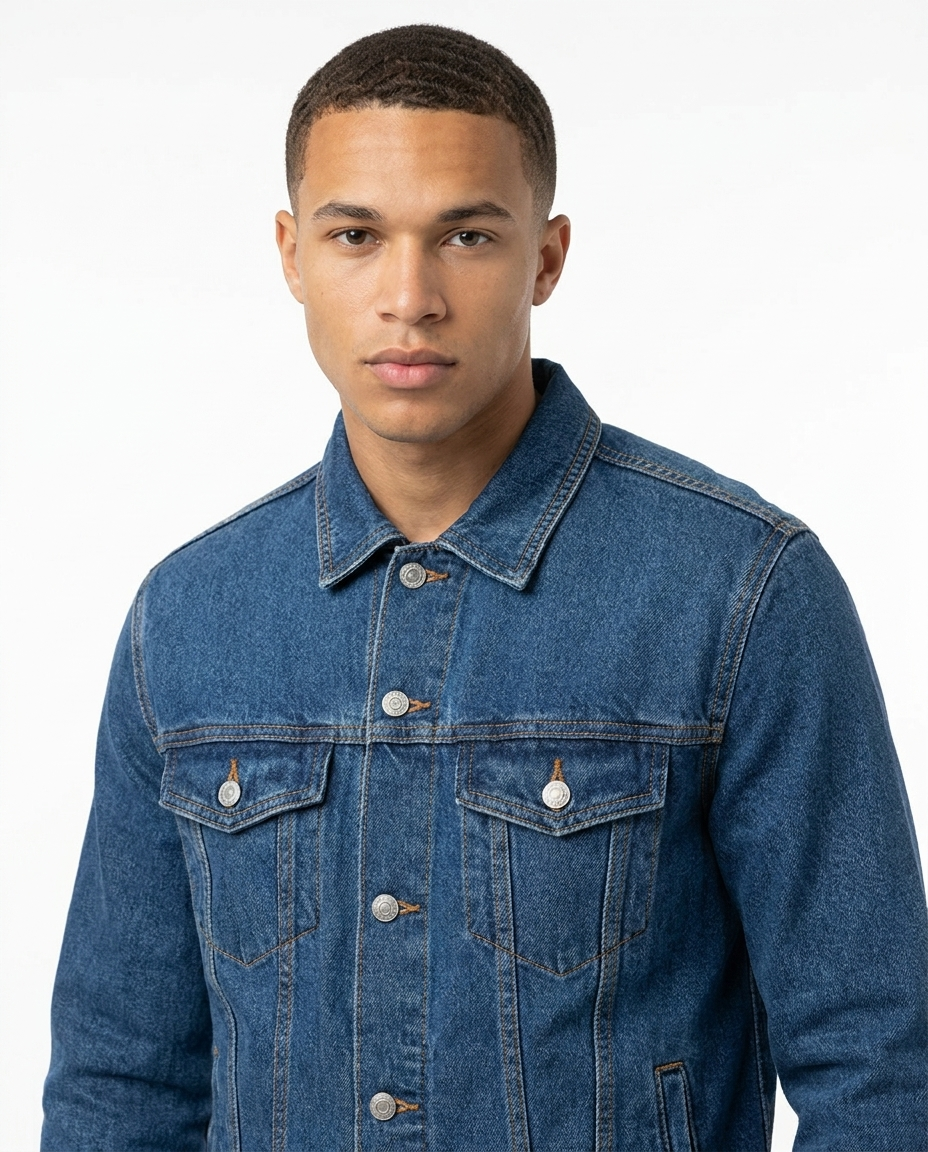

**2. Fotografia de campana editorial (Lifestyle / Exterior):**

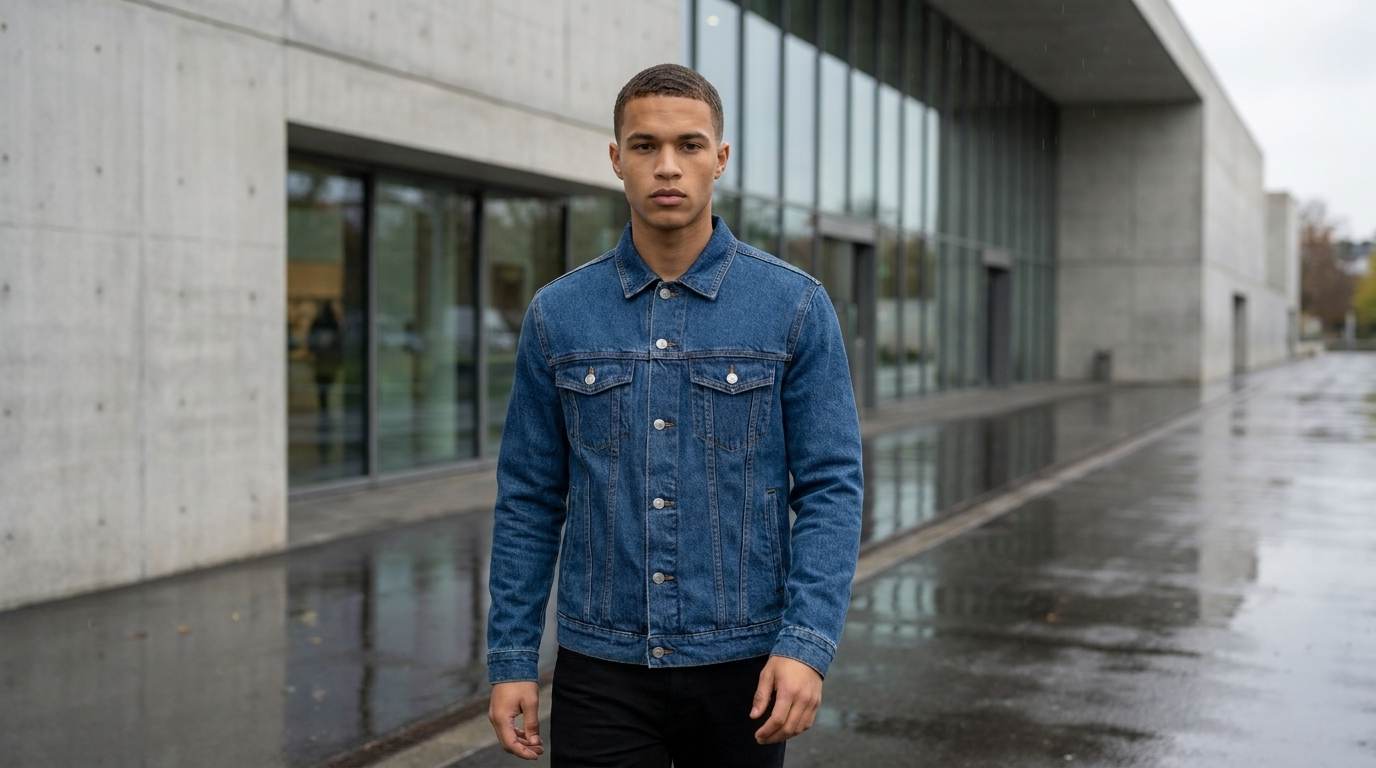

In [ ]:

# Creación de las rutas de los archivos generados en la carpeta assets
ruta_catalogo = "assets/catalogo_estudio1.jpg"
ruta_editorial = "assets/campana_editorial1.jpg"

display(
    Markdown("### Muestra de Resultados Visuales Generados a partir de los Prompts")
)

# Visualizacion de la fotografia de catalogo
if os.path.exists(ruta_catalogo):
    display(Markdown("**1. Fotografia de catalogo e-commerce (Estudio):**"))
    display(IPyImage(filename=ruta_catalogo, width=450))
else:
    print(
        f"Aviso: Guarda la imagen generada de catalogo en '{ruta_catalogo}' para visualizarla."
    )

# Visualizacion de la fotografia editorial
if os.path.exists(ruta_editorial):
    display(
        Markdown(
            "**2. Fotografia de campana editorial (Lifestyle / Exterior):**"
        )
    )
    display(IPyImage(filename=ruta_editorial, width=450))
else:
    print(
        f"Aviso: Guarda la imagen generada de editorial en '{ruta_editorial}' para visualizarla."
    )